<a href="https://colab.research.google.com/github/aaohl-lanlan/ia-ciberseguranca/blob/main/Notebook_da_Aula_3_Detec%C3%A7%C3%A3o_de_Intrus%C3%A3o01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA para Cibersegurança — Aula 3
## Dados e features em segurança: classificação de ataques e clustering (CIC-IDS2017)

**Dupla:** `Allan Accioly`  ·  `Lucas Freitas`

> Rodem as células na ordem.

Nesta aula prática vamos trabalhar com **tráfego de rede real** do CIC-IDS2017 e percorrer, de ponta a ponta:
dados → EDA → preparação → **Random Forest** (supervisionado) → feature importance → **K-Means** (não supervisionado) → comparação.

O foco é **entender os dados e as features de segurança** e ver, na prática, a diferença entre classificar ataques (com rótulos) e descobrir grupos (sem rótulos).

## 2. Bibliotecas e configuração

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix,
                             balanced_accuracy_score, f1_score, silhouette_score)

sns.set_theme(style='whitegrid')
RANDOM_SEED = 33
np.random.seed(RANDOM_SEED)

## 3. Carregamento dos dados

O dataset completo é pesado (vários GB, ~2,8 milhões de fluxos). Para a aula, baixamos a versão **MachineLearningCVE** (os CSVs já com as features de fluxo + coluna `Label`) e, mais adiante, trabalhamos com uma **amostra** para manter tudo leve.

In [ ]:
# Download (mesmo pacote usado nas aulas anteriores)
# Alternativa oficial (pode exigir formulário):
# !wget 'http://205.174.165.80/CICDataset/CIC-IDS-2017/Dataset/CIC-IDS-2017/CSVs/MachineLearningCSV.zip' -O CIC_IDS_2017.zip
!gdown '1X9s72a_9VzukVbFhGKHW1xLnyrnqu3MP' -O CIC_IDS_2017.zip
!unzip -q -o CIC_IDS_2017.zip

Downloading...
From (original): https://drive.google.com/uc?id=1X9s72a_9VzukVbFhGKHW1xLnyrnqu3MP
From (redirected): https://drive.google.com/uc?id=1X9s72a_9VzukVbFhGKHW1xLnyrnqu3MP&confirm=t&uuid=e79fcd39-b213-4c41-8d3a-aacb6dc3bd90
To: /content/CIC_IDS_2017.zip
100% 235M/235M [00:02<00:00, 109MB/s]


In [ ]:
# Carrega e concatena todos os CSVs
df_list = []
for file in os.listdir('MachineLearningCVE/'):
    df_list.append(pd.read_csv(f'MachineLearningCVE/{file}'))
df = pd.concat(df_list, ignore_index=True)
del df_list

# Alguns nomes de coluna vêm com espaços no início/fim
df.columns = df.columns.str.strip()
print('Dimensões:', df.shape)
df.head()

Dimensões: (2830743, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
print('Coluna alvo: Label ->', df['Label'].unique()[:8], '...')
df.info()

Coluna alvo: Label -> ['BENIGN' 'DoS slowloris' 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye'
 'Heartbleed' 'Web Attack � Brute Force' 'Web Attack � XSS'] ...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Pack

### Verificando problemas nos dados
O CIC-IDS2017 tem três problemas conhecidos: **registros duplicados**, **valores NaN** e **valores infinitos** (em features como `Flow Bytes/s`, que dividem por tempo e podem estourar).

In [ ]:
print('Duplicatas :', df.duplicated().sum())
print('NaN totais :', int(df.isna().sum().sum()))
inf_cols = [c for c in df.select_dtypes(include=[np.number]).columns
            if np.isinf(df[c]).any()]
print('Colunas com valores infinitos:', inf_cols)

Duplicatas : 308381
NaN totais : 1358
Colunas com valores infinitos: ['Flow Bytes/s', 'Flow Packets/s']


### Limpeza
Descartamos duplicatas e NaN; para os infinitos, seguimos a abordagem das aulas anteriores — substituir pelo **maior valor finito** da coluna, preservando o registro.

In [ ]:
ini = len(df)
df = df.drop_duplicates().dropna().reset_index(drop=True)
print(f'Duplicatas/NaN removidos: {ini - len(df)}  |  restam {len(df)} registros')

for col in df.select_dtypes(include=[np.number]).columns:
    mask_inf = np.isinf(df[col])
    if mask_inf.any():
        df.loc[mask_inf, col] = df.loc[~mask_inf, col].max()
print('Infinitos tratados. Dimensões:', df.shape)

Duplicatas/NaN removidos: 308734  |  restam 2522009 registros
Infinitos tratados. Dimensões: (2522009, 79)


Padronizamos os rótulos de *web attacks*, que vêm com caracteres estranhos de codificação.

In [ ]:
df['Label'] = (df['Label'].str.replace('Web Attack.*Brute Force', 'Web Attack - Brute Force', regex=True)
                            .str.replace('Web Attack.*XSS', 'Web Attack - XSS', regex=True)
                            .str.replace('Web Attack.*Sql Injection', 'Web Attack - Sql Injection', regex=True))
df['Label'].value_counts()

,count
Label,
BENIGN,2096134
DoS Hulk,172846
DDoS,128016
PortScan,90819
DoS GoldenEye,10286
FTP-Patator,5933
DoS slowloris,5385
DoS Slowhttptest,5228
SSH-Patator,3219


### Amostra de trabalho
Para o notebook rodar rápido em qualquer máquina, tiramos uma **amostra estratificada** (~200 mil fluxos), preservando a proporção original entre classes. Assim mantemos o desbalanceamento realista, mas com custo baixo.

In [ ]:
N_ALVO = 200_000
if len(df) > N_ALVO:
    frac = N_ALVO / len(df)
    df = (df.groupby('Label', group_keys=False)
            .apply(lambda g: g.sample(max(1, int(round(len(g) * frac))), random_state=RANDOM_SEED))
            .reset_index(drop=True))
print('Amostra de trabalho:', df.shape)

/tmp/ipykernel_527/1716381155.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(max(1, int(round(len(g) * frac))), random_state=RANDOM_SEED))


Amostra de trabalho: (200001, 79)


## 4. EDA simples

Comecemos pelo essencial: **quanto do tráfego é ataque** e **quais ataques** aparecem.

NameError: name 'groupby' is not defined

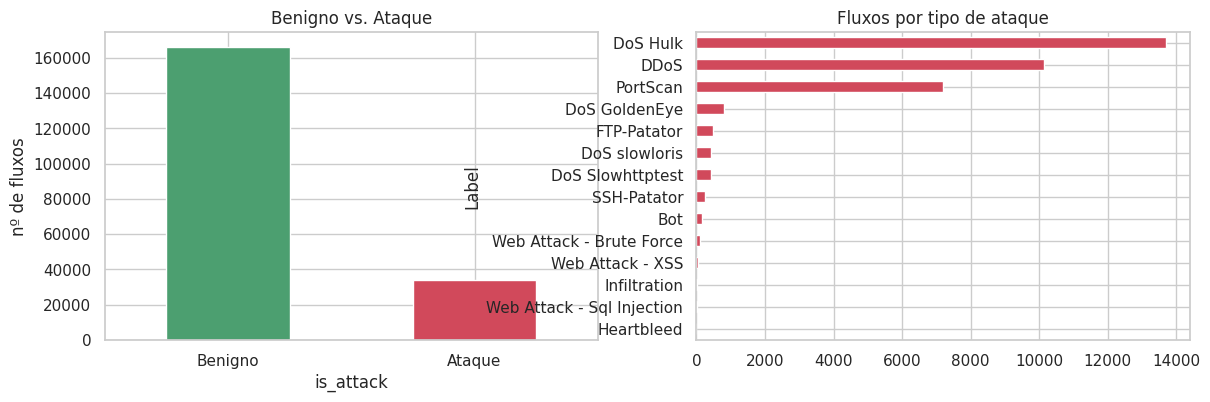

In [ ]:
df['is_attack'] = (df['Label'] != 'BENIGN').astype(int)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
df['is_attack'].map({0:'Benigno', 1:'Ataque'}).value_counts().plot(
    kind='bar', ax=ax[0], color=['#4C9F70', '#D1495B'])
ax[0].set_title('Benigno vs. Ataque'); ax[0].set_ylabel('nº de fluxos')
ax[0].tick_params(axis='x', rotation=0)

ataques = df[df['Label'] != 'BENIGN']['Label'].value_counts()
ataques.plot(kind='barh', ax=ax[1], color='#D1495B')
ax[1].set_title('Fluxos por tipo de ataque'); ax[1].invert_yaxis()
groupby('DDoS').describe()
plt.tight_layout(); plt.show()

**O que observar:** o tráfego é **fortemente desbalanceado** — a imensa maioria é benigna, e entre os ataques alguns tipos (DoS Hulk, PortScan, DDoS) dominam enquanto outros têm pouquíssimos exemplos. Isso afeta tanto o treino quanto a escolha de métricas mais adiante.

Vamos olhar a escala de algumas features numéricas típicas de fluxo.

In [ ]:
cols_interesse = ['Flow Duration', 'Flow Bytes/s', 'Total Fwd Packets',
                  'Average Packet Size', 'SYN Flag Count']
df[cols_interesse].describe()

,Flow Duration,Flow Bytes/s,Total Fwd Packets,Average Packet Size,SYN Flag Count
count,2.000010e+05,2.000010e+05,200001.000000,200001.000000,200001.000000
mean,1.661503e+07,2.478871e+06,8.591942,212.057809,0.048555
std,3.525746e+07,5.320310e+07,669.678968,344.657488,0.214936
min,-1.000000e+00,-1.200000e+07,1.000000,0.000000,0.000000
25%,2.080000e+02,1.197184e+02,2.000000,9.000000,0.000000
50%,5.039300e+04,3.774322e+03,2.000000,81.000000,0.000000
75%,5.325546e+06,1.106719e+05,6.000000,179.933333,0.000000
max,1.200000e+08,2.071000e+09,214125.000000,2920.000000,1.000000


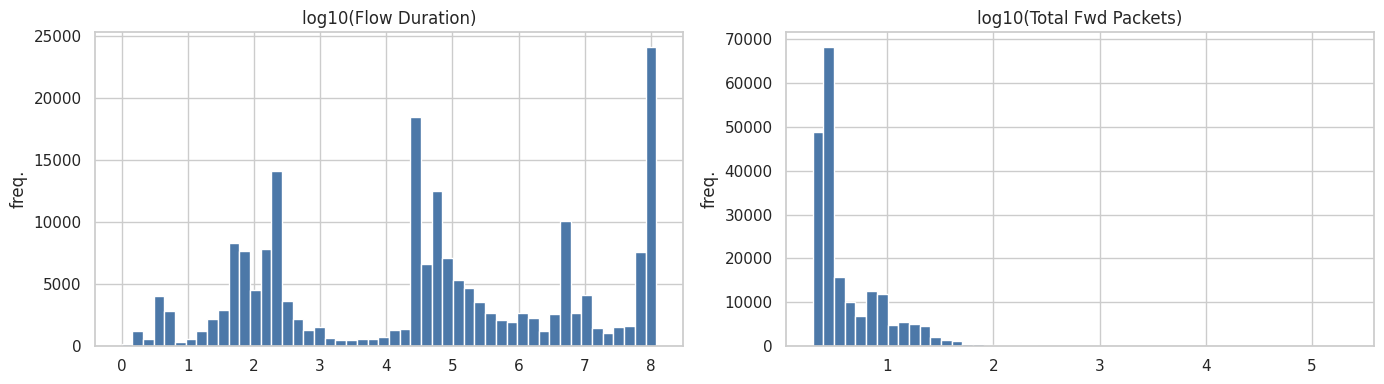

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for a, col in zip(ax, ['Flow Duration', 'Total Fwd Packets']):
    vals = df[col].clip(lower=0) + 1
    a.hist(np.log10(vals), bins=50, color='#4C78A8')
    a.set_title(f'log10({col})'); a.set_ylabel('freq.')
plt.tight_layout(); plt.show()

**O que observar:** distribuições muito assimétricas e de cauda longa — comuns em tráfego de rede. É por isso que, para modelos baseados em distância (K-Means), a **padronização** será importante.

Comparando uma feature entre benigno e alguns ataques (boxplot).

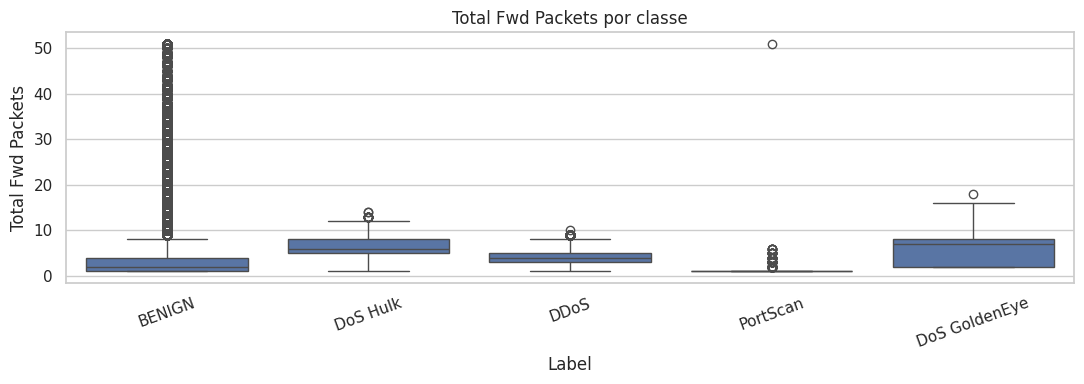

In [ ]:
top_ataques = df[df['Label'] != 'BENIGN']['Label'].value_counts().head(4).index.tolist()
sub = df[df['Label'].isin(['BENIGN'] + top_ataques)].copy()
sub['Total Fwd Packets'] = sub['Total Fwd Packets'].clip(upper=sub['Total Fwd Packets'].quantile(0.99))

plt.figure(figsize=(11, 4))
sns.boxplot(data=sub, x='Label', y='Total Fwd Packets',
            order=['BENIGN'] + top_ataques)
plt.xticks(rotation=20); plt.title('Total Fwd Packets por classe'); plt.tight_layout(); plt.show()

**O que observar:** algumas classes de ataque têm distribuição de pacotes bem diferente do tráfego benigno — é exatamente esse tipo de separação que o modelo vai explorar.

Correlação entre um subconjunto de features (para não poluir com 78 colunas).

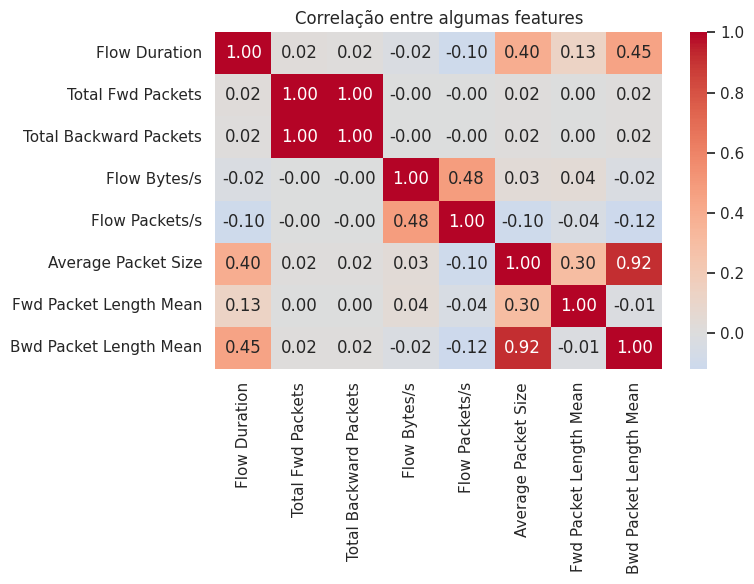

In [ ]:
cols_corr = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
             'Flow Bytes/s', 'Flow Packets/s', 'Average Packet Size',
             'Fwd Packet Length Mean', 'Bwd Packet Length Mean']
cols_corr = [c for c in cols_corr if c in df.columns]
plt.figure(figsize=(8, 6))
sns.heatmap(df[cols_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação entre algumas features'); plt.tight_layout(); plt.show()

**O que observar:** pares de features muito correlacionados (ex.: contagens e tamanhos de pacote) carregam informação redundante — algo a considerar ao escolher features.

## 5. Preparação dos dados

- **Alvo:** vamos classificar **Benigno (0) vs. Ataque (1)** — um problema binário, claro para começar.
- **Features:** todas as colunas numéricas de fluxo.
- **Data leakage:** fazemos o `train_test_split` **antes** de qualquer ajuste que dependa dos dados (aqui o Random Forest nem precisa de normalização; a padronização entra só no K-Means, ajustada no conjunto certo).

In [ ]:
y = (df['Label'] != 'BENIGN').astype(int)
X = df.select_dtypes(include=[np.number]).drop(columns=['is_attack'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_SEED)

print('Treino:', X_train.shape, '| Teste:', X_test.shape)
print('Proporção de ataque — treino: {:.1%} | teste: {:.1%}'.format(y_train.mean(), y_test.mean()))

Treino: (140000, 78) | Teste: (60001, 78)
Proporção de ataque — treino: 16.9% | teste: 16.9%


## 6. Modelo supervisionado — Random Forest

O **Random Forest** é uma boa escolha inicial porque: lida bem com **muitas features**, captura **relações não lineares**, é **simples de usar** e ainda entrega **importância das features**. Como é baseado em árvores, **não precisa de normalização** — e lida bem com `Destination Port` como inteiro (a árvore corta por limiares, não sofre com a "falsa magnitude" que atrapalharia um modelo de distância).

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    n_jobs=-1, random_state=RANDOM_SEED)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print('Treino concluído.')

Treino concluído.


### Avaliação
Com dados desbalanceados, **acurácia sozinha engana**. Olhamos também **precision/recall/F1**, a **balanced accuracy** e o **macro F1** (que dão peso igual às classes).

              precision    recall  f1-score   support

     Benigno       1.00      1.00      1.00     49869
      Ataque       1.00      0.99      0.99     10132

    accuracy                           1.00     60001
   macro avg       1.00      1.00      1.00     60001
weighted avg       1.00      1.00      1.00     60001

Balanced accuracy: 0.9955
Macro F1        : 0.9963


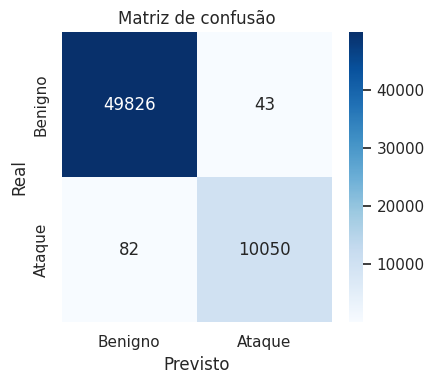

In [ ]:
print(classification_report(y_test, y_pred, target_names=['Benigno', 'Ataque']))
print('Balanced accuracy:', round(balanced_accuracy_score(y_test, y_pred), 4))
print('Macro F1        :', round(f1_score(y_test, y_pred, average='macro'), 4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benigno', 'Ataque'], yticklabels=['Benigno', 'Ataque'])
plt.xlabel('Previsto'); plt.ylabel('Real'); plt.title('Matriz de confusão'); plt.tight_layout(); plt.show()

**O que observar:** onde estão os erros? Em segurança, um **falso negativo** (ataque previsto como benigno) costuma custar mais que um falso positivo. A matriz de confusão mostra qual dos dois o modelo comete mais.

## 7. Feature Importance

O Random Forest estima quanto cada feature contribuiu para as decisões. Vejamos as 15 mais importantes.

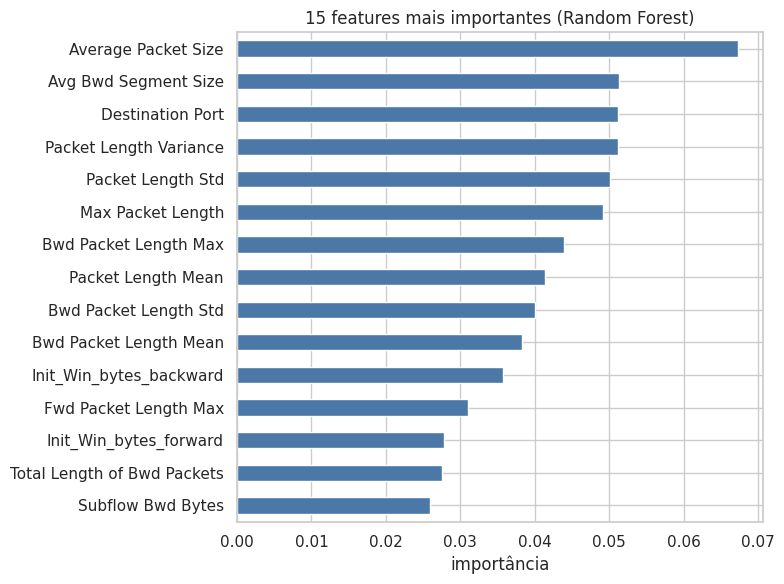

,0
Average Packet Size,0.067290
Avg Bwd Segment Size,0.051376
Destination Port,0.051181
Packet Length Variance,0.051130
Packet Length Std,0.050127
Max Packet Length,0.049122
Bwd Packet Length Max,0.043934
Packet Length Mean,0.041405
Bwd Packet Length Std,0.040102
Bwd Packet Length Mean,0.038223


In [ ]:
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top15 = importancias.head(15)

plt.figure(figsize=(8, 6))
top15[::-1].plot(kind='barh', color='#4C78A8')
plt.title('15 features mais importantes (Random Forest)')
plt.xlabel('importância'); plt.tight_layout(); plt.show()
top15

## 8. Modelo não supervisionado — K-Means

Agora **esquecemos os rótulos** e perguntamos: os fluxos formam **grupos naturais**? O K-Means agrupa por **distância**, então duas coisas importam:
1. Precisamos **padronizar** as features (senão `Flow Bytes/s`, na casa dos milhares, domina `SYN Flag Count`, que é ~0–2).
2. Removemos `Destination Port`: como é um inteiro, a distância trataria a porta 44720 como "muito maior" que a 80, o que **não tem sentido semântico** num modelo de distância (diferente da árvore, que a usa sem problema).

In [ ]:
X_clu = X.drop(columns=[c for c in ['Destination Port'] if c in X.columns])
scaler = StandardScaler().fit(X_clu)
X_scaled = scaler.transform(X_clu)
print('Matriz para clustering:', X_scaled.shape)

Matriz para clustering: (200001, 77)


### Escolhendo `k` — Elbow + Silhouette
Rodamos K-Means para vários `k` e olhamos a **inércia** (cotovelo) e o **silhouette score**. Para ficar rápido, calculamos numa **subamostra** de 5 mil fluxos.

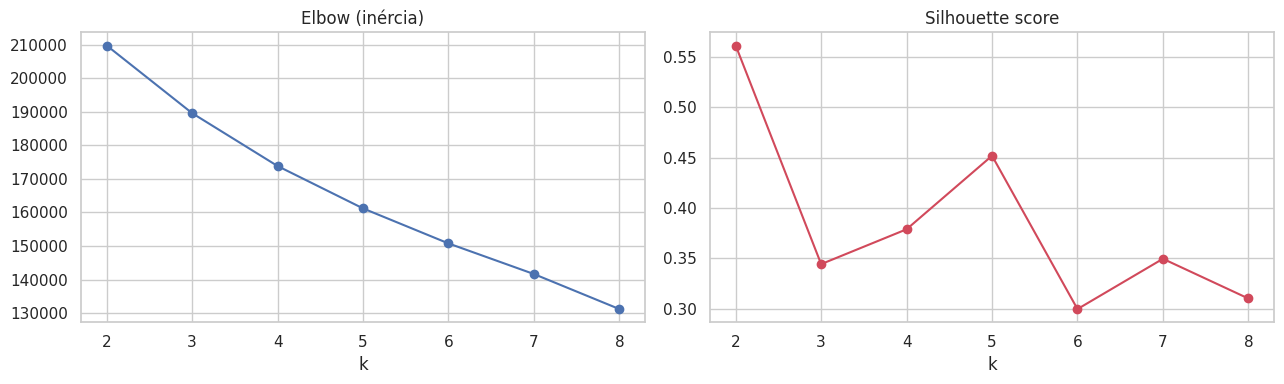

In [ ]:
idx = np.random.choice(len(X_scaled), size=min(5000, len(X_scaled)), replace=False)
X_sub = X_scaled[idx]

ks, inertias, sils = range(2, 9), [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_SEED).fit(X_sub)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_sub, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(list(ks), inertias, 'o-'); ax[0].set_title('Elbow (inércia)'); ax[0].set_xlabel('k')
ax[1].plot(list(ks), sils, 'o-', color='#D1495B'); ax[1].set_title('Silhouette score'); ax[1].set_xlabel('k')
plt.tight_layout(); plt.show()

In [ ]:
K = 4
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_SEED).fit(X_scaled)
df['cluster'] = kmeans.labels_

# Quantos fluxos de cada rótulo real caíram em cada cluster?
pd.crosstab(df['cluster'], df['Label'])

Label,BENIGN,Bot,DDoS,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,DoS slowloris,FTP-Patator,Heartbleed,Infiltration,PortScan,SSH-Patator,Web Attack - Brute Force,Web Attack - Sql Injection,Web Attack - XSS
cluster,,,,,,,,,,,,,,,
0,129276,152,3752,122,1379,105,166,470,0,0,7180,255,112,0,51
1,6041,0,1712,126,11164,82,112,0,0,1,9,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,30908,3,4688,568,1164,228,149,0,1,2,13,0,5,2,1


## 8b. Visualização com PCA
Os dados têm dezenas de dimensões. Usamos **PCA** para projetar em 2D só para **visualizar** — comparando lado a lado os clusters do K-Means e os rótulos reais.

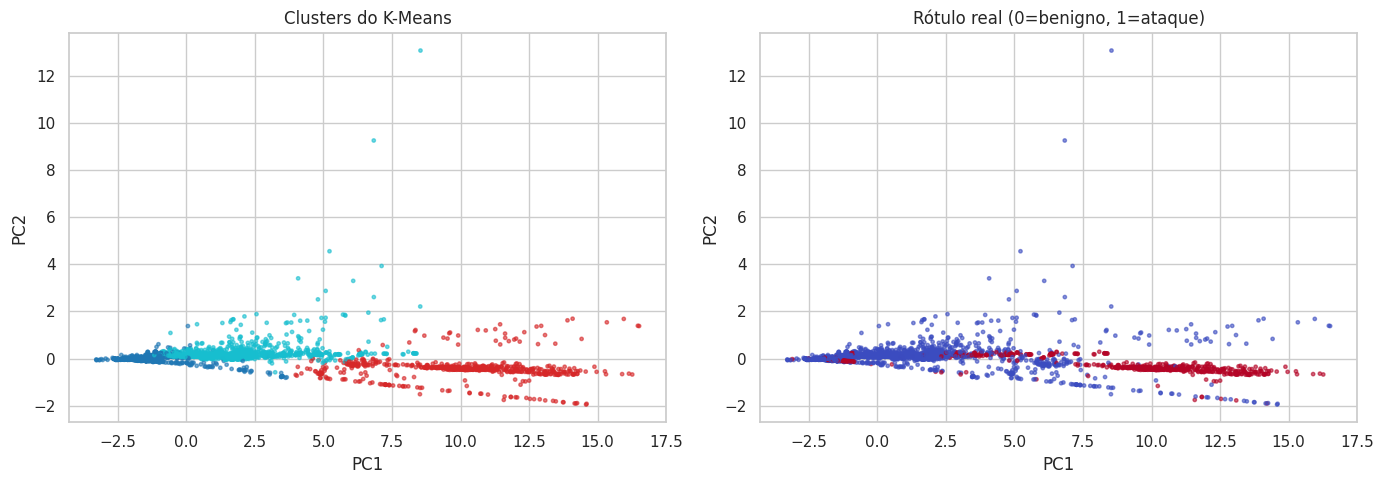

Variância explicada pelos 2 PCs: [0.217, 0.11]


In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_SEED)
Z = pca.fit_transform(X_scaled)

vis = np.random.choice(len(Z), size=min(6000, len(Z)), replace=False)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(Z[vis, 0], Z[vis, 1], c=df['cluster'].values[vis], cmap='tab10', s=6, alpha=0.6)
ax[0].set_title('Clusters do K-Means')

cores = pd.factorize(df['is_attack'].values)[0]
sc = ax[1].scatter(Z[vis, 0], Z[vis, 1], c=df['is_attack'].values[vis], cmap='coolwarm', s=6, alpha=0.6)
ax[1].set_title('Rótulo real (0=benigno, 1=ataque)')
for a in ax: a.set_xlabel('PC1'); a.set_ylabel('PC2')
plt.tight_layout(); plt.show()
print('Variância explicada pelos 2 PCs:', pca.explained_variance_ratio_.round(3).tolist())

## 9. Supervisionado vs. não supervisionado

| Abordagem     | Usa rótulos? | Objetivo          | Exemplo aqui                 |
| ------------- | ------------ | ----------------- | ---------------------------- |
| Random Forest | Sim          | Classificar       | Benigno vs. Ataque           |
| K-Means       | Não          | Encontrar grupos  | Agrupar padrões de tráfego   |

**Quando usar cada um, na prática:**
- **Supervisionado** quando você **tem rótulos confiáveis** de ataques passados e quer detectar os **conhecidos** com alta precisão.
- **Não supervisionado** quando **faltam rótulos** ou você quer descobrir **comportamento novo/anômalo** — útil para ataques que ainda não foram vistos (retomamos isso na aula 6, com detecção de anomalias).

## 10. Exercícios

**1 — EDA:** escolha **três features** e investigue como seus valores diferem entre tráfego benigno e ataques (use boxplots ou `groupby('Label').describe()`).

**2 — Random Forest:** treine de novo usando um **subconjunto diferente de features** (por exemplo, só as relacionadas a pacotes) e compare as métricas.

**3 — Feature Importance:** **remova as 5 features mais importantes** e treine de novo. O desempenho cai muito? O que isso diz sobre redundância entre features?

**4 — Clustering:** teste **outros valores de `k`** no K-Means e compare pelo **silhouette score**. Qual `k` parece melhor?

**5 — Investigação:** compare (com `pd.crosstab`) os **clusters** com os **rótulos reais** e discuta por que eles são — ou não — parecidos.

### Exercício 1: EDA de Features Selecionadas

In [ ]:
print('1 — EDA: Comparando as features Flow Duration, Total Fwd Packets e Average Packet Size entre tráfego benigno e ataques.')

features_to_explore = ['Flow Duration', 'Total Fwd Packets', 'Average Packet Size']

for feature in features_to_explore:
    print(f'\n--- Feature: {feature} ---')
    # Group by Label and describe the selected feature
    display(df.groupby('Label')[feature].describe())

1 — EDA: Comparando as features Flow Duration, Total Fwd Packets e Average Packet Size entre tráfego benigno e ataques.

--- Feature: Flow Duration ---


,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
BENIGN,166227.0,1.218452e+07,3.122644e+07,-1.0,2.020000e+02,38093.0,1.048732e+06,119999971.0
Bot,155.0,2.893913e+05,4.264162e+05,3.0,4.750000e+01,68979.0,6.119695e+05,1060655.0
DDoS,10152.0,1.702989e+07,3.102933e+07,21.0,6.185472e+05,1886936.5,9.406022e+06,102657286.0
DoS GoldenEye,816.0,2.529816e+07,2.978477e+07,780.0,1.061363e+07,11613725.0,2.239058e+07,119634581.0
DoS Hulk,13707.0,7.617667e+07,3.688752e+07,1.0,8.373191e+07,86126059.0,9.902706e+07,119288440.0
DoS Slowhttptest,415.0,5.979073e+07,3.609462e+07,3.0,2.099951e+07,63121954.0,6.315902e+07,115511391.0
DoS slowloris,427.0,6.264846e+07,4.919362e+07,2.0,3.002883e+06,100000704.0,1.036570e+08,119016069.0
FTP-Patator,470.0,5.982788e+06,4.292780e+06,80.0,2.510000e+02,8642807.5,9.186986e+06,10515308.0
Heartbleed,1.0,1.193027e+08,NaN,119302728.0,1.193027e+08,119302728.0,1.193027e+08,119302728.0



--- Feature: Total Fwd Packets ---


,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
BENIGN,166227.0,9.331246,734.477342,1.0,1.00,2.0,4.00,214125.0
Bot,155.0,2.883871,3.207043,1.0,1.00,3.0,4.00,35.0
DDoS,10152.0,4.486702,1.895148,1.0,3.00,4.0,5.00,10.0
DoS GoldenEye,816.0,5.860294,3.053324,2.0,2.00,7.0,8.00,18.0
DoS Hulk,13707.0,6.372364,2.023311,1.0,5.00,6.0,8.00,14.0
DoS Slowhttptest,415.0,5.833735,3.295264,1.0,4.00,7.0,7.00,19.0
DoS slowloris,427.0,6.819672,5.750100,1.0,2.00,3.0,14.00,16.0
FTP-Patator,470.0,6.640426,3.308654,2.0,2.00,9.0,9.00,9.0
Heartbleed,1.0,2685.000000,NaN,2685.0,2685.00,2685.0,2685.00,2685.0



--- Feature: Average Packet Size ---


,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
BENIGN,166227.0,131.351713,202.765014,0.00000,9.000000,78.500000,132.500000,2920.000000
Bot,155.0,44.138020,186.944799,3.00000,6.000000,9.000000,48.714286,1813.269565
DDoS,10152.0,815.129907,659.428501,6.00000,7.500000,897.615385,1453.375000,1937.833333
DoS GoldenEye,816.0,536.664357,388.674123,0.00000,0.000000,498.812500,918.807692,1118.818182
DoS Hulk,13707.0,854.357600,326.988961,0.00000,822.133333,918.076923,996.083333,1715.142857
DoS Slowhttptest,415.0,126.755022,269.538775,0.00000,0.000000,0.000000,76.285714,1983.000000
DoS slowloris,427.0,58.968480,72.235319,0.00000,0.000000,6.000000,140.941177,320.333333
FTP-Patator,470.0,11.255408,1.503083,0.00000,9.333333,12.062500,12.291667,14.000000
Heartbleed,1.0,1713.913910,NaN,1713.91391,1713.913910,1713.913910,1713.913910,1713.913910


Exercicio 2 - Random Forest

In [ ]:
y = (df['Label'] != 'BENIGN').astype(int)
X = df.select_dtypes(include=[np.number]).drop(columns=['is_attack'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_SEED)

print('Treino:', X_train.shape, '| Teste:', X_test.shape)
print('Proporção de ataque — treino: {:.1%} | teste: {:.1%}'.format(y_train.mean(), y_test.mean()))

### Exercício 2: Random Forest com subconjunto de features (apenas relacionadas a pacotes)

In [ ]:
# Selecionar features relacionadas a pacotes
packet_features = [
    'Total Fwd Packets',
    'Total Backward Packets',
    'Fwd Packet Length Max',
    'Fwd Packet Length Min',
    'Fwd Packet Length Mean',
    'Fwd Packet Length Std',
    'Bwd Packet Length Max',
    'Bwd Packet Length Min',
    'Bwd Packet Length Mean',
    'Bwd Packet Length Std',
    'Min Packet Length',
    'Max Packet Length',
    'Packet Length Mean',
    'Packet Length Std',
    'Packet Length Variance',
    'Average Packet Size',
    'Fwd Packets/s',
    'Bwd Packets/s',
    'Subflow Fwd Packets',
    'Subflow Bwd Packets',
    'act_data_pkt_fwd'
]

# Filtrar as features que realmente existem no DataFrame X
packet_features_existent = [f for f in packet_features if f in X.columns]

X_packet = X[packet_features_existent]

# Dividir os dados novamente com o novo subconjunto de features
X_train_packet, X_test_packet, y_train, y_test = train_test_split(
    X_packet, y, test_size=0.3, stratify=y, random_state=RANDOM_SEED)

print('Treino (apenas pacotes):', X_train_packet.shape, '| Teste (apenas pacotes):', X_test_packet.shape)
print('Proporção de ataque — treino: {:.1%} | teste: {:.1%}'.format(y_train.mean(), y_test.mean()))

Treino (apenas pacotes): (140000, 21) | Teste (apenas pacotes): (60001, 21)
Proporção de ataque — treino: 16.9% | teste: 16.9%


In [ ]:
# Treinar um novo modelo Random Forest com as features de pacote
rf_packet = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    n_jobs=-1, random_state=RANDOM_SEED)
rf_packet.fit(X_train_packet, y_train)
y_pred_packet = rf_packet.predict(X_test_packet)
print('Treino com features de pacote concluído.')

Treino com features de pacote concluído.


#### Avaliação do Random Forest com features de pacote

              precision    recall  f1-score   support

     Benigno       1.00      1.00      1.00     49869
      Ataque       0.98      0.98      0.98     10132

    accuracy                           0.99     60001
   macro avg       0.99      0.99      0.99     60001
weighted avg       0.99      0.99      0.99     60001

Balanced accuracy: 0.9898
Macro F1        : 0.9896


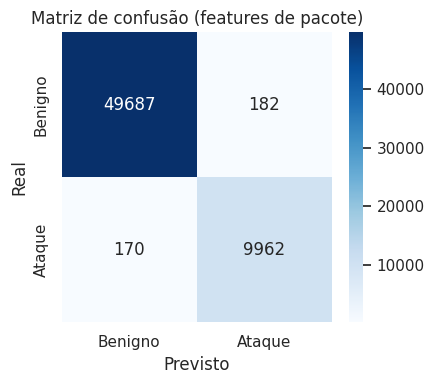

In [ ]:
print(classification_report(y_test, y_pred_packet, target_names=['Benigno', 'Ataque']))
print('Balanced accuracy:', round(balanced_accuracy_score(y_test, y_pred_packet), 4))
print('Macro F1        :', round(f1_score(y_test, y_pred_packet, average='macro'), 4))

cm_packet = confusion_matrix(y_test, y_pred_packet)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm_packet, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benigno', 'Ataque'], yticklabels=['Benigno', 'Ataque'])
plt.xlabel('Previsto'); plt.ylabel('Real'); plt.title('Matriz de confusão (features de pacote)'); plt.tight_layout(); plt.show()

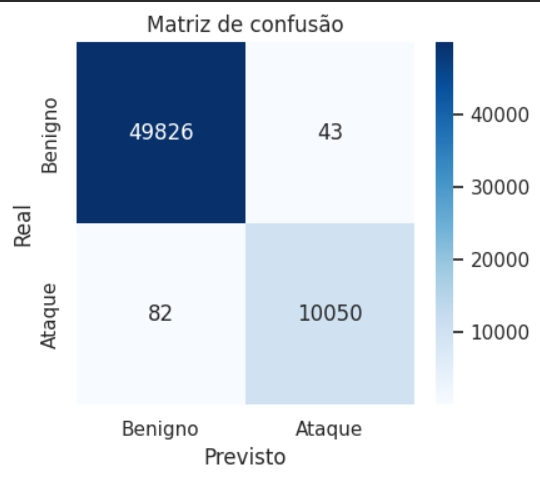

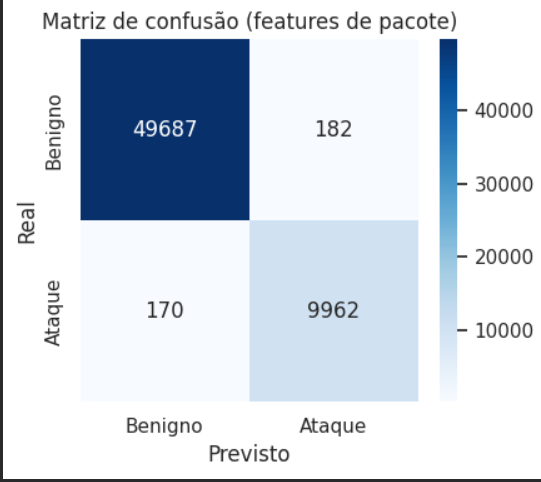

### Exercício 3: Random Forest sem as 5 features mais importantes

In [ ]:
# Identificar as 5 features mais importantes
top_5_features = importancias.head(5).index.tolist()
print(f"As 5 features mais importantes são: {top_5_features}")

# Criar um novo DataFrame X sem essas 5 features
X_reduced = X.drop(columns=top_5_features)

# Dividir os dados novamente com o conjunto de features reduzido
X_train_reduced, X_test_reduced, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.3, stratify=y, random_state=RANDOM_SEED)

print('Treino (features reduzidas):', X_train_reduced.shape, '| Teste (features reduzidas):', X_test_reduced.shape)
print('Proporção de ataque — treino: {:.1%} | teste: {:.1%}'.format(y_train.mean(), y_test.mean()))

As 5 features mais importantes são: ['Average Packet Size', 'Avg Bwd Segment Size', 'Destination Port', 'Packet Length Variance', 'Packet Length Std']
Treino (features reduzidas): (140000, 73) | Teste (features reduzidas): (60001, 73)
Proporção de ataque — treino: 16.9% | teste: 16.9%


In [ ]:
# Treinar um novo modelo Random Forest com as features reduzidas
rf_reduced = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    n_jobs=-1, random_state=RANDOM_SEED)
rf_reduced.fit(X_train_reduced, y_train)
y_pred_reduced = rf_reduced.predict(X_test_reduced)
print('Treino com features reduzidas concluído.')

Treino com features reduzidas concluído.


#### Avaliação do Random Forest com features reduzidas

              precision    recall  f1-score   support

     Benigno       1.00      1.00      1.00     49869
      Ataque       0.99      0.99      0.99     10132

    accuracy                           1.00     60001
   macro avg       1.00      1.00      1.00     60001
weighted avg       1.00      1.00      1.00     60001

Balanced accuracy: 0.9955
Macro F1        : 0.996


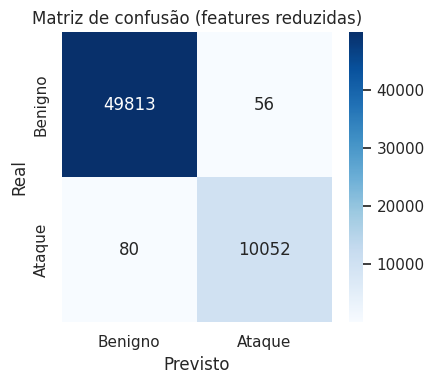

In [ ]:
print(classification_report(y_test, y_pred_reduced, target_names=['Benigno', 'Ataque']))
print('Balanced accuracy:', round(balanced_accuracy_score(y_test, y_pred_reduced), 4))
print('Macro F1        :', round(f1_score(y_test, y_pred_reduced, average='macro'), 4))

cm_reduced = confusion_matrix(y_test, y_pred_reduced)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm_reduced, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benigno', 'Ataque'], yticklabels=['Benigno', 'Ataque'])
plt.xlabel('Previsto'); plt.ylabel('Real'); plt.title('Matriz de confusão (features reduzidas)'); plt.tight_layout(); plt.show()

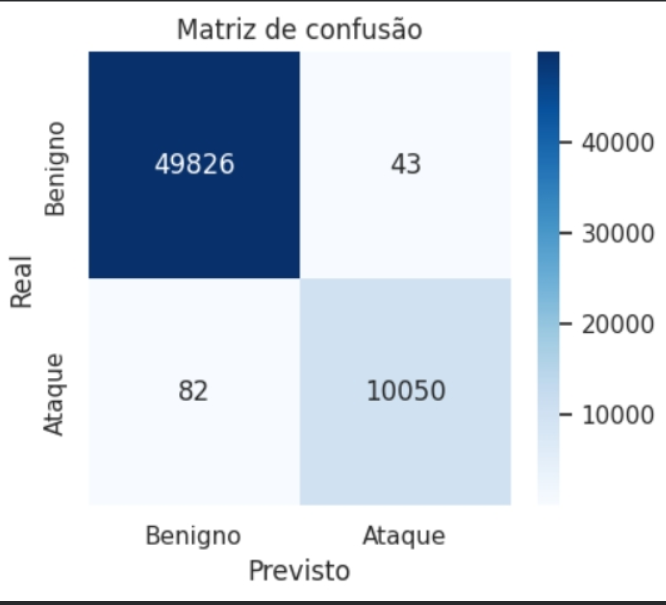

Houve pouca queda no desempenho, isso se dando por conta da relativa  redundância entre as features.

Exercicio 4

In [ ]:
X_clu = X.drop(columns=[c for c in ['Destination Port'] if c in X.columns])
scaler = StandardScaler().fit(X_clu)
X_scaled = scaler.transform(X_clu)
print('Matriz para clustering:', X_scaled.shape)

Matriz para clustering: (200001, 77)


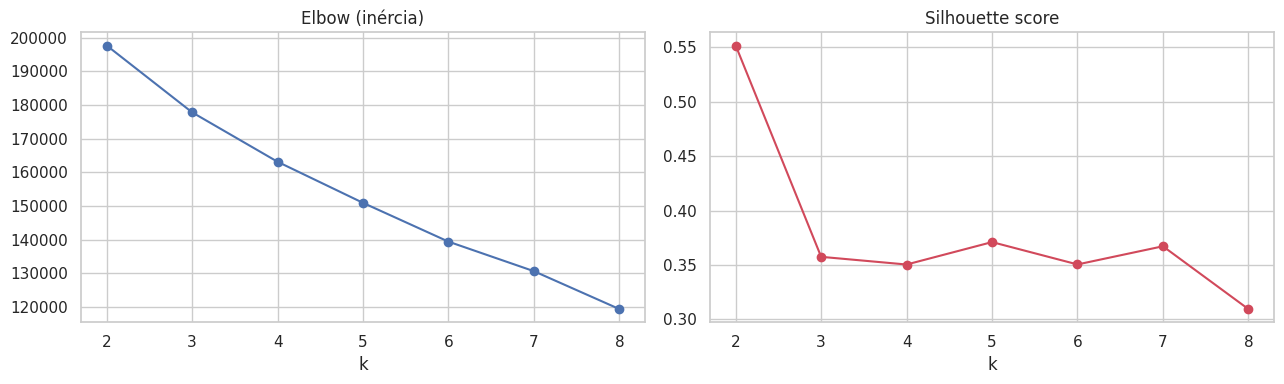

In [ ]:
idx = np.random.choice(len(X_scaled), size=min(5000, len(X_scaled)), replace=False)
X_sub = X_scaled[idx]

ks, inertias, sils = range(2, 9), [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_SEED).fit(X_sub)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_sub, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(list(ks), inertias, 'o-'); ax[0].set_title('Elbow (inércia)'); ax[0].set_xlabel('k')
ax[1].plot(list(ks), sils, 'o-', color='#D1495B'); ax[1].set_title('Silhouette score'); ax[1].set_xlabel('k')
plt.tight_layout(); plt.show()

MOdificado ( K = 8)

parece ser melhor pois demostra ser menos abstrato

In [ ]:
K = 8
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_SEED).fit(X_scaled)
df['cluster'] = kmeans.labels_

# Quantos fluxos de cada rótulo real caíram em cada cluster?
crosstab_result = pd.crosstab(df['cluster'], df['Label'])
display(crosstab_result)

# Discussão: Comparando clusters com rótulos reais
# Os clusters do K-Means não se alinham perfeitamente com os rótulos reais de 'BENIGN' e 'Ataque'.
# Observações:
# - Alguns clusters (como o Cluster 0 e 4) contêm a vasta maioria do tráfego 'BENIGN', mas também um número significativo de ataques.
# - Outros clusters (como o Cluster 7) têm uma proporção maior de ataques (principalmente DDoS e DoS Hulk), embora ainda contenham algum tráfego benigno.
# - O K-Means agrupou os dados com base na similaridade das features (distância), não na etiqueta de ser ataque ou não.
# - A 'pureza' dos clusters (i.e., a homogeneidade de rótulos dentro de um cluster) é mista. Muitos clusters são heterogêneos.
# - Isso mostra que as características que definem a 'similaridade' para o K-Means nem sempre são as mesmas que definem 'ataque' para a classificação supervisionada.
# - Para detecção de anomalias, um cluster predominantemente benigno com alguns fluxos de ataque poderia ser interessante para investigação, ou vice-versa, um cluster predominantemente de ataque com alguns benignos pode indicar padrões de tráfego atípicos.
# - A escolha de K (8 neste caso) influencia diretamente como esses agrupamentos são formados. Com K=4, a granularidade seria menor, resultando em clusters mais amplos e, possivelmente, mais heterogêneos.

Label,BENIGN,Bot,DDoS,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,DoS slowloris,FTP-Patator,Heartbleed,Infiltration,PortScan,SSH-Patator,Web Attack - Brute Force,Web Attack - Sql Injection,Web Attack - XSS
cluster,,,,,,,,,,,,,,,
0,116681,151,3752,111,1368,35,149,313,0,0,7140,20,109,0,51
1,3456,1,0,1,3529,91,157,0,0,1,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2399,0,0,136,2,0,92,0,0,0,10,0,0,0,0
4,34017,3,2040,440,924,229,12,0,0,1,13,235,8,2,1
5,9576,0,0,0,5,60,17,157,0,1,39,0,0,0,0
6,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,95,0,4360,128,7879,0,0,0,1,0,0,0,0,0,0


original ( k = 4 ) resutado:

In [ ]:
K = 4
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_SEED).fit(X_scaled)
df['cluster'] = kmeans.labels_

# Quantos fluxos de cada rótulo real caíram em cada cluster?
pd.crosstab(df['cluster'], df['Label'])

Label,BENIGN,Bot,DDoS,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,DoS slowloris,FTP-Patator,Heartbleed,Infiltration,PortScan,SSH-Patator,Web Attack - Brute Force,Web Attack - Sql Injection,Web Attack - XSS
cluster,,,,,,,,,,,,,,,
0,129276,152,3752,122,1379,105,166,470,0,0,7180,255,112,0,51
1,6041,0,1712,126,11164,82,112,0,0,1,9,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,30908,3,4688,568,1164,228,149,0,1,2,13,0,5,2,1


# Respostas_atividade_3



1.   Os valores infinitos na coluna *Flow Bytes/s* surgem da divisão do total de bytes por durações nulas ou quase zero em fluxos extremamente rápidos. Eles não podem permanecer na base porque inviabilizam cálculos de média e variância, quebram etapas de pré-processamento como o *StandardScaler* e distorcem drasticamente a escala de algoritmos baseados em distância (como K-Means e redes neurais), gerando erros numéricos; dessa forma, substituir os infinitos pelo maior valor finito da coluna é a estratégia ideal para preservar a informação de altíssima velocidade do fluxo sem comprometer a matemática do modelo.


------------------------------------------

2.  Deixar duplicatas na base pode gerar *overfitting* — fazendo o modelo memorizar registros em vez de aprender padrões gerais — e inflar artificialmente as métricas de avaliação por contaminação entre treino e teste, enquanto a remoção automática de valores ausentes (NaNs) deve ser evitada para não ocasionar a perda crítica de dados em classes raras nem viés de seleção diante de falhas sistemáticas. Por isso, a melhor abordagem é recorrer a técnicas de imputação (como preenchimento por média, mediana ou constante) para preservar a integridade da amostra, descartando registros ou colunas apenas quando o volume de NaNs for elevado a ponto de torná-los estatisticamente inviáveis.  

------------------------------------------

3.  Em cenários de alto desbalanceamento de classes — identificados na EDA por gráficos de contagem —, a acurácia é uma métrica enganosa, pois um modelo que preveja apenas a classe majoritária parecerá eficaz sem detectar nenhum ataque. Gráfico de Contagem (Bar Chart): Um gráfico de barras simples do Label mostrará uma disparidade visual enorme entre a barra da classe majoritária e as outras.


------------------------------------------


4. A diferença fundamental entre modelos baseados em distância e em árvores reside na sensibilidade à escala das variáveis: enquanto o K-Means utiliza a distância euclidiana — fazendo com que features de grande magnitude (como Flow Bytes/s) dominem o cálculo e tornem variáveis menores irrelevantes sem a devida padronização —, a Random Forest avalia cada variável de forma independente por meio de divisões (splits), o que garante que a magnitude dos dados não altere a importância relativa nem a eficácia do modelo.

------------------------------------------
5. A utilidade de uma feature depende diretamente do seu poder de separação: quando apresenta distribuições claras e distintas (evidenciadas por boxplots separados), ela atua como um excelente discriminador que permite a criação de regras simples e precisas de decisão em modelos como a Random Forest, ao passo que distribuições sobrepostas ou similares indicam baixo valor informativo individual, forçando o algoritmo a depender de combinações complexas entre variáveis ou resultando em um alto erro de previsão.



